In [69]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

with open('../data/hyperparameters/best_hyperparameters.txt', 'r') as file:
    lines = file.readlines()

data = []
for line in lines[1:]:
    line = line.strip().split('\t')
    try:
        hyperparams = ast.literal_eval(line[2])  # Use ast.literal_eval
    except (SyntaxError, ValueError):
        print(f"Error evaluating literal on line: {line}")
        continue

    data.append([float(line[1])] + list(hyperparams.values()))

columns = ['Metric Value'] + list(hyperparams.keys())
df = pd.DataFrame(data, columns=columns)
df = df.rename_axis('ID').reset_index()

df_sorted = df.sort_values(by='Metric Value', ascending=False)
df_sorted

,ID,Metric Value,width_1,lr,batch_size,optimizer
19,19,0.687101,32,0.01000,512,SGD
5,5,0.680680,64,0.01000,1024,Adam
21,21,0.679723,32,0.00100,512,AdamW
10,10,0.678153,8,0.00010,1024,RMSprop
0,0,0.677708,16,0.00010,128,AdamW
15,15,0.677041,64,0.00001,1024,Adam
8,8,0.676857,8,0.00001,1024,AdamW
16,16,0.674861,128,0.00100,64,SGD
6,6,0.674384,64,0.00100,512,Adam
11,11,0.673535,16,0.00100,64,AdamW


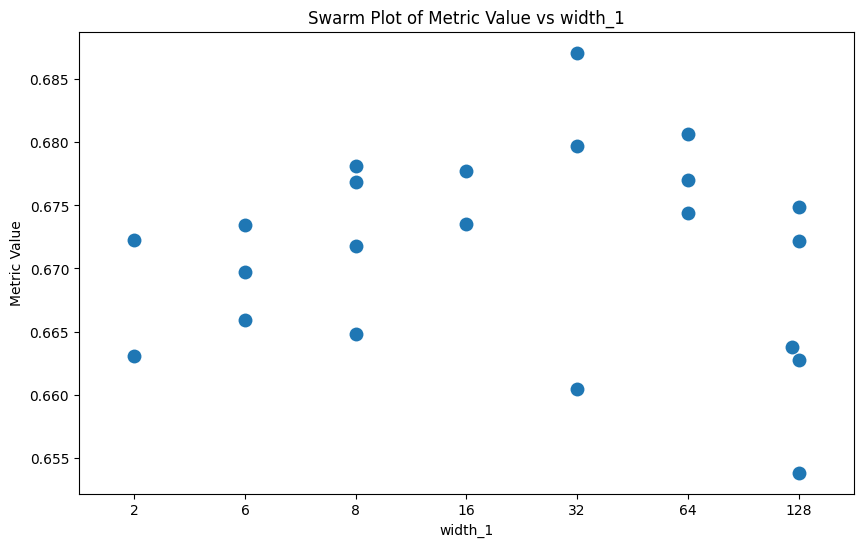

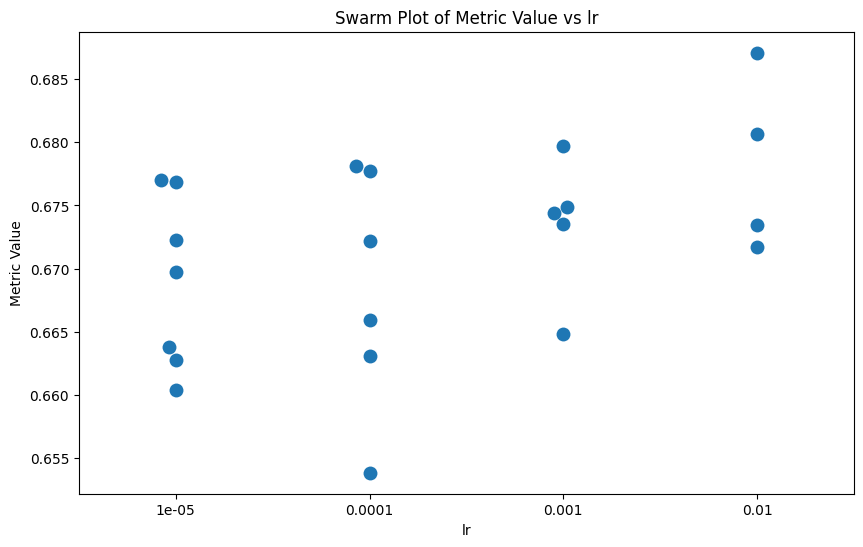

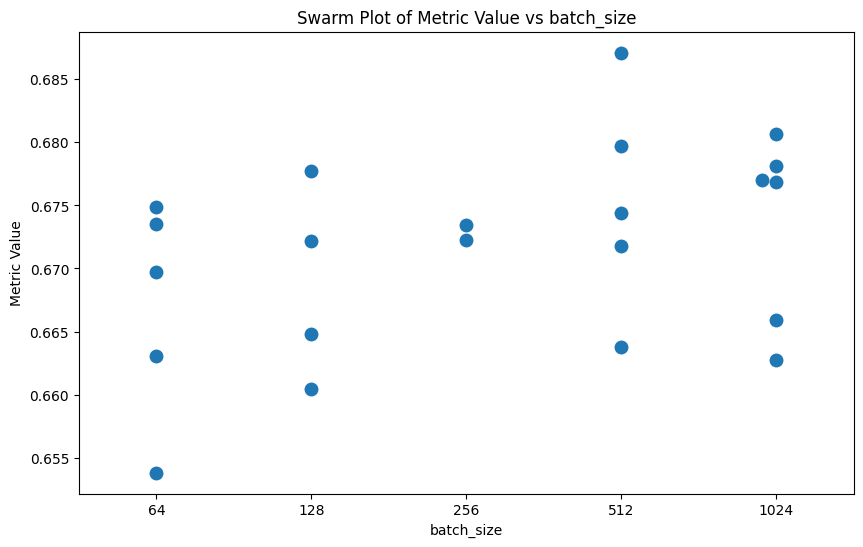

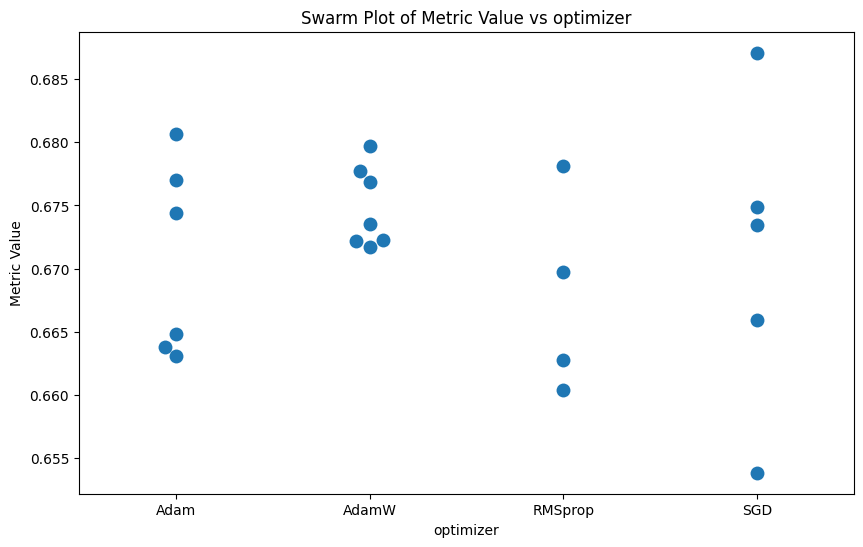

In [77]:
for hyperparam in list(hyperparams.keys()):
    plt.figure(figsize=(10, 6))
    sns.swarmplot(data=df_sorted, x=hyperparam, y='Metric Value', s=10)
    plt.title(f'Swarm Plot of Metric Value vs {hyperparam}')
    plt.xlabel(hyperparam)
    plt.ylabel('Metric Value')
    plt.savefig(f"../plots/hyperparam_optimization/{hyperparam}.pdf", dpi=600) 
    plt.show()

In [71]:
    if hyperparam == 'lr' or hyperparam == 'width_1' or hyperparam == 'batch_size':
        plt.xscale('log') 